In [1]:
%matplotlib inline

In [2]:
import numpy as np
import astropy.io.fits as pyfits
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.stats import binned_statistic

In [3]:
## this is just to define a colourmap to nicely show the disc energy shift
# normalisation for redshift
redshift_vmin = 0.01
redshift_vmax = 1.2
redshift_normpl = 1.
redshift_norm = colors.Normalize(redshift_vmin, redshift_vmax)
# colour map for redshift
redshift_cdict = {'blue': [(0.0, 0, 0),
                           (0.35, 0, 0),
                           (0.8, 0, 0),
                           (0.97, 1, 1),
                           (1.0, 0.6, 0.6)],
                  'green': [(0.0, 0, 0),
                            (0.2, 0, 0),
                            (0.6, 1, 1),
                            (0.75, 1, 1),
                            (0.8, 0.75, 0.75),
                            (0.85, 1.0, 1.0),
                            (0.93, 1.0, 1.0),
                            (0.99, 0, 0),
                            (1.0, 0, 0)],
                  'red': [(0.0, 0, 0),
                          (0.001, 0.5, 0.5),
                          (0.2, 1, 1),
                          (0.7, 1, 1),
                          (0.8, 0, 0),
                          (1.0, 0, 0)]}
redshift_map = colors.LinearSegmentedColormap('RedshiftMap', redshift_cdict)

In [5]:
image_filename = '../dat/imageplane_rk45.fits'
with pyfits.open(image_filename) as fits_file:
    disc_enshift = np.array(fits_file['ENSHIFT'].data)    # energy shift from each pixel to observer
    disc_r = np.array(fits_file['RADIUS'].data)      # radius on the disc seen in each pixel
    disc_phi = np.array(fits_file['PHI'].data)       # azimuthal angle on the disc seen in each pixel
    disc_flux = np.array(fits_file['FLUX'].data)        # flux from each pixel
    disc_time = np.array(fits_file['TIME'].data)        # time delay from each pixel to observer
    disc_emis = np.array(fits_file['EMIS'].data)        # emissivity from each pixel
    
disc_enshift[np.isnan(disc_enshift)] = 0

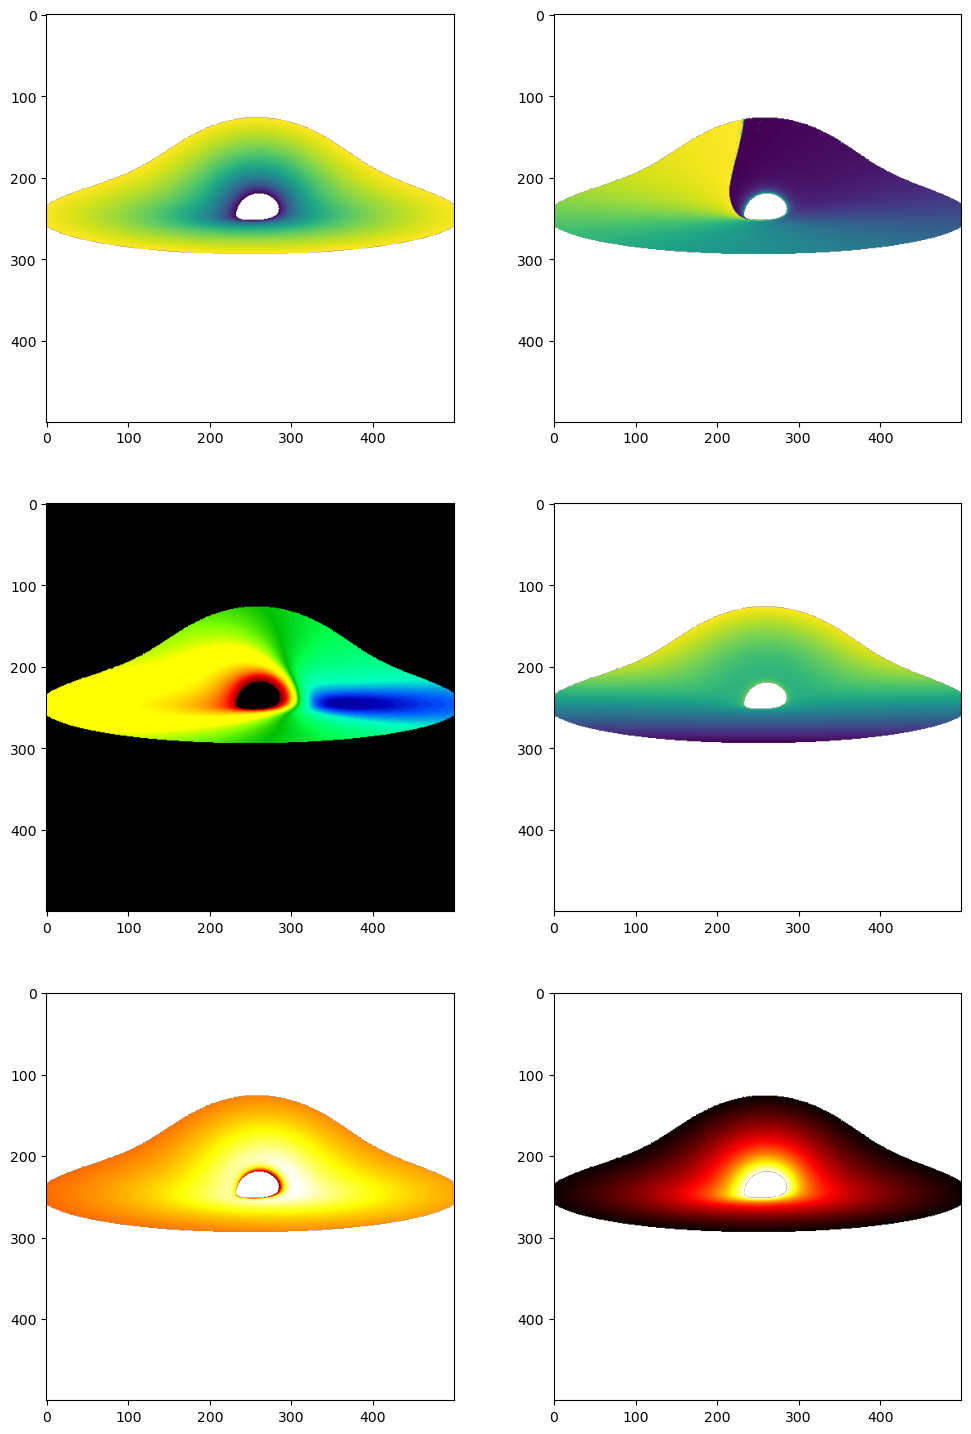

In [6]:
fig, ax = plt.subplots(3,2, figsize=(12, 18))
ax[0,0].imshow(np.flipud(disc_r), norm=colors.LogNorm(), cmap='viridis')
ax[0,1].imshow(np.flipud(disc_phi), norm=colors.Normalize(vmin=-np.pi, vmax=np.pi), cmap='viridis')
ax[1,0].imshow(np.flipud(disc_enshift), norm=redshift_norm, cmap=redshift_map)
ax[1,1].imshow(np.flipud(disc_time), norm=colors.LogNorm(), cmap='viridis')
ax[2,0].imshow(np.flipud(disc_flux), norm=colors.LogNorm(), cmap='hot')
ax[2,1].imshow(np.flipud(disc_emis), norm=colors.LogNorm(), cmap='hot')

In [10]:
image_filename = '../dat/imageplane_rk4.fits'
with pyfits.open(image_filename) as fits_file:
    disc_enshift = np.array(fits_file['ENSHIFT'].data)    # energy shift from each pixel to observer
    disc_r = np.array(fits_file['RADIUS'].data)      # radius on the disc seen in each pixel
    disc_phi = np.array(fits_file['PHI'].data)       # azimuthal angle on the disc seen in each pixel
    disc_flux = np.array(fits_file['FLUX'].data)        # flux from each pixel
    disc_time = np.array(fits_file['TIME'].data)        # time delay from each pixel to observer
    disc_emis = np.array(fits_file['EMIS'].data)        # emissivity from each pixel
    
disc_enshift[np.isnan(disc_enshift)] = 0

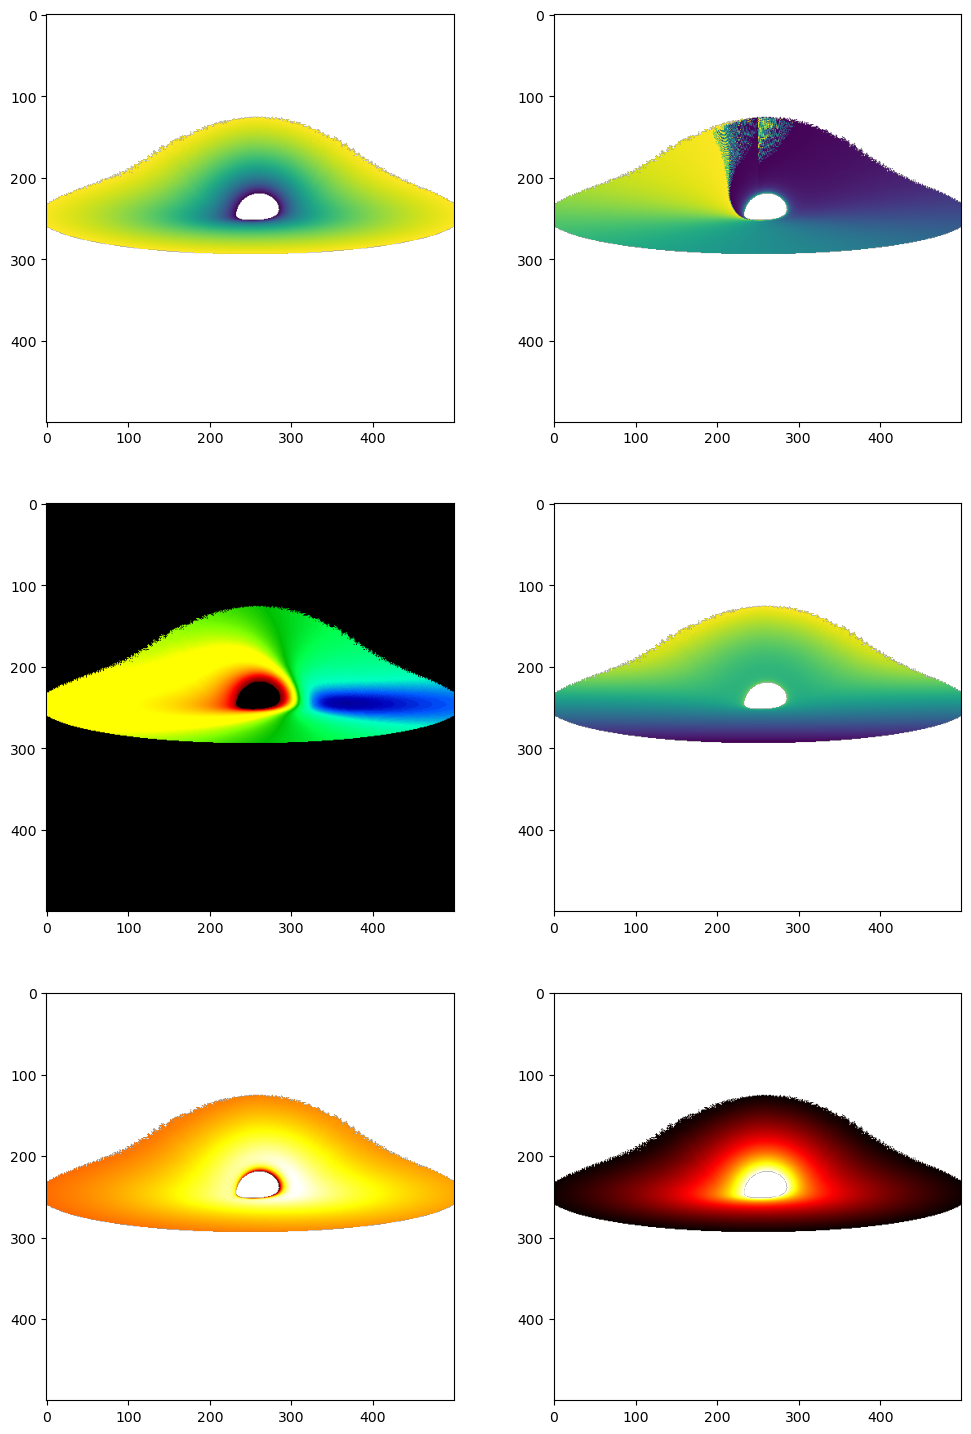

In [11]:
fig, ax = plt.subplots(3,2, figsize=(12, 18))
ax[0,0].imshow(np.flipud(disc_r), norm=colors.LogNorm(), cmap='viridis')
ax[0,1].imshow(np.flipud(disc_phi), norm=colors.Normalize(vmin=-np.pi, vmax=np.pi), cmap='viridis')
ax[1,0].imshow(np.flipud(disc_enshift), norm=redshift_norm, cmap=redshift_map)
ax[1,1].imshow(np.flipud(disc_time), norm=colors.LogNorm(), cmap='viridis')
ax[2,0].imshow(np.flipud(disc_flux), norm=colors.LogNorm(), cmap='hot')
ax[2,1].imshow(np.flipud(disc_emis), norm=colors.LogNorm(), cmap='hot')

In [8]:
image_filename = '../dat/imageplane_euler.fits'
with pyfits.open(image_filename) as fits_file:
    disc_enshift = np.array(fits_file['ENSHIFT'].data)    # energy shift from each pixel to observer
    disc_r = np.array(fits_file['RADIUS'].data)      # radius on the disc seen in each pixel
    disc_phi = np.array(fits_file['PHI'].data)       # azimuthal angle on the disc seen in each pixel
    disc_flux = np.array(fits_file['FLUX'].data)        # flux from each pixel
    disc_time = np.array(fits_file['TIME'].data)        # time delay from each pixel to observer
    disc_emis = np.array(fits_file['EMIS'].data)        # emissivity from each pixel
    
disc_enshift[np.isnan(disc_enshift)] = 0

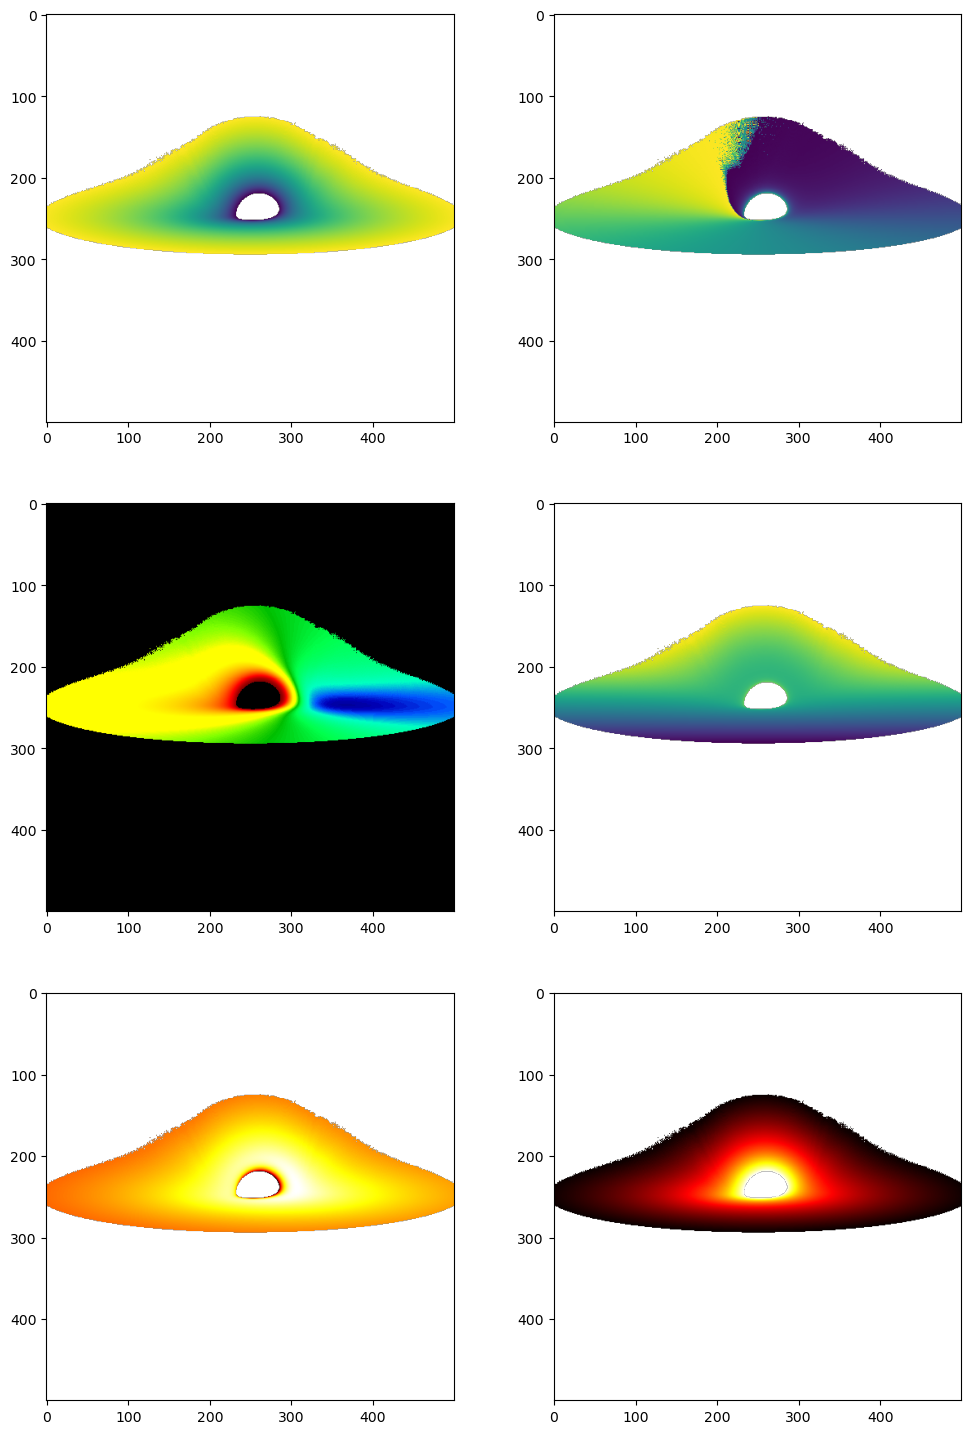

In [9]:
fig, ax = plt.subplots(3,2, figsize=(12, 18))
ax[0,0].imshow(np.flipud(disc_r), norm=colors.LogNorm(), cmap='viridis')
ax[0,1].imshow(np.flipud(disc_phi), norm=colors.Normalize(vmin=-np.pi, vmax=np.pi), cmap='viridis')
ax[1,0].imshow(np.flipud(disc_enshift), norm=redshift_norm, cmap=redshift_map)
ax[1,1].imshow(np.flipud(disc_time), norm=colors.LogNorm(), cmap='viridis')
ax[2,0].imshow(np.flipud(disc_flux), norm=colors.LogNorm(), cmap='hot')
ax[2,1].imshow(np.flipud(disc_emis), norm=colors.LogNorm(), cmap='hot')

In [12]:

# Load all three integrators — RK45 (imageplane_test.fits) is used as the reference
def load_fits(filename):
    with pyfits.open(filename) as f:
        return {
            'radius':  np.array(f['RADIUS'].data),
            'enshift': np.array(f['ENSHIFT'].data),
            'flux':    np.array(f['FLUX'].data),
        }

data = {
    'Euler': load_fits('../dat/imageplane_euler.fits'),
    'RK4':   load_fits('../dat/imageplane_rk4.fits'),
    'RK45':  load_fits('../dat/imageplane_test.fits'),
}

# Mask: pixels where all three integrators have a valid (nonzero) hit
mask = (data['Euler']['radius'] > 0) & (data['RK4']['radius'] > 0) & (data['RK45']['radius'] > 0)
print(f"Pixels with disc hit in all three: {mask.sum()} / {mask.size}")


Pixels with disc hit in all three: 52241 / 250000


/var/folders/bm/8zvkr0y11_x7b0n4dmyv33r40000gp/T/ipykernel_32028/3659157088.py:11: RuntimeWarning: divide by zero encountered in divide
  diff = np.where(mask, (data[method][qty] - ref) / ref, np.nan)
/var/folders/bm/8zvkr0y11_x7b0n4dmyv33r40000gp/T/ipykernel_32028/3659157088.py:11: RuntimeWarning: invalid value encountered in divide
  diff = np.where(mask, (data[method][qty] - ref) / ref, np.nan)


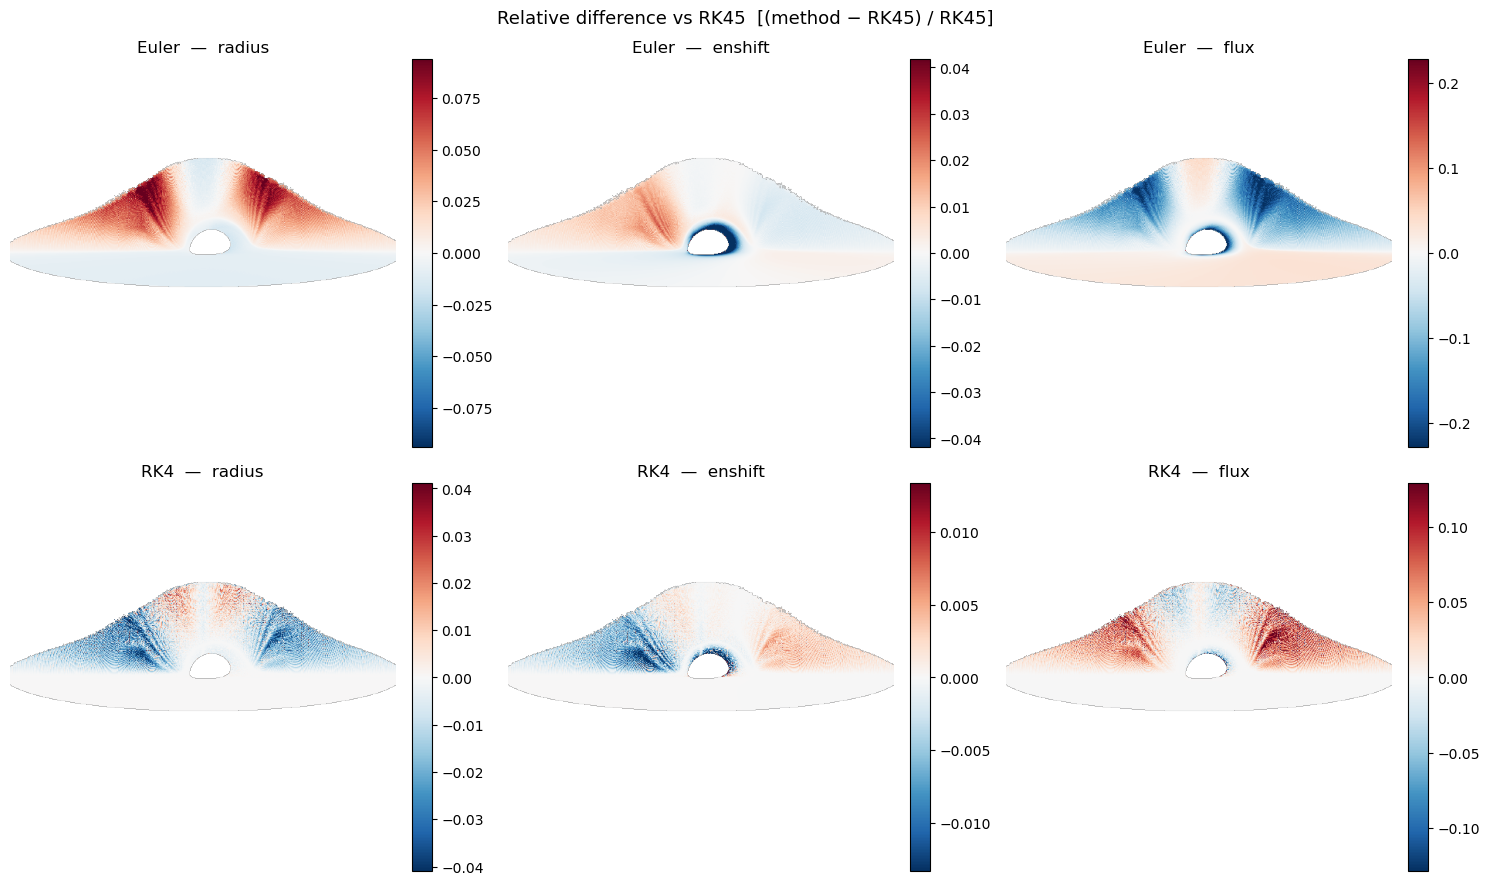

In [13]:

# Relative difference maps vs RK45 reference for each quantity
quantities = ['radius', 'enshift', 'flux']
methods    = ['Euler', 'RK4']

fig, axes = plt.subplots(len(methods), len(quantities), figsize=(15, 9))
fig.suptitle('Relative difference vs RK45  [(method − RK45) / RK45]', fontsize=13)

for row, method in enumerate(methods):
    for col, qty in enumerate(quantities):
        ref = data['RK45'][qty]
        diff = np.where(mask, (data[method][qty] - ref) / ref, np.nan)

        vmax = np.nanpercentile(np.abs(diff), 99)
        im = axes[row, col].imshow(np.flipud(diff),
                                   norm=colors.Normalize(vmin=-vmax, vmax=vmax),
                                   cmap='RdBu_r', origin='upper')
        axes[row, col].set_title(f'{method}  —  {qty}')
        axes[row, col].axis('off')
        plt.colorbar(im, ax=axes[row, col], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [14]:

# Summary statistics: mean absolute relative error and RMS relative error vs RK45
print(f"{'Method':<8}  {'Quantity':<10}  {'Mean |Δ|/ref':>14}  {'RMS Δ/ref':>12}  {'Max |Δ|/ref':>13}")
print("-" * 65)
for method in ['Euler', 'RK4']:
    for qty in quantities:
        ref  = data['RK45'][qty][mask]
        diff = (data[method][qty][mask] - ref) / ref
        print(f"{method:<8}  {qty:<10}  {np.mean(np.abs(diff)):>14.6f}  {np.sqrt(np.mean(diff**2)):>12.6f}  {np.max(np.abs(diff)):>13.6f}")
    print()


Method    Quantity      Mean |Δ|/ref     RMS Δ/ref    Max |Δ|/ref
-----------------------------------------------------------------
Euler     radius            0.021209      0.030557       0.144928
Euler     enshift           0.005168      0.010611       0.223950
Euler     flux              0.054761      0.077619       0.501181

RK4       radius            0.006452      0.011602       0.083077
RK4       enshift           0.001599      0.003607       0.144877
RK4       flux              0.018874      0.034858       0.309922

